# Assignment 2 
**IND 320 -  Data to Decision 2025** \
by Amelie Leonardi

**Statement of the use of the AI:** 

I used ChatGPT (GPT-5.0), Gemini and GitHub Copilot in VS Code to accelerate routine coding. Espacially AI was used to try to fix the problem with spark. Further it was used to help with the figures and the connection to MongoDB. I reviewed, adapted, and tested all suggestions; modeling choices and plots are my own. No synthetic data was generated, and no confidential data was shared.

GitHub Url: https://github.com/amelieleo/IND320_2025_amelieleo.git 

Streamlit URL: https://ind3202025amelieleo-rxo74zsldlt6bs6rqfwxvn.streamlit.app/

## Log

**The Notebook**

First I started fetching the data from the Elhub API. I used o for-loop to get the data for one year. I connect to cassandra and spark. Unfortunally spark can't save any data to cassandra or my harddrive. I had a talk with Kristian and he allowed me to skip the cassandra part, because we couldn't find a fix for my problem. Further I prepared the DataFrame so that it matches the required output from cassandra. 

*Pie Chart:* First I tried the pie chart just with the data as we have it. Due to the disbalance between the produced energy of the different groups the pie chart was hard to read. I decided to summarize all the small production groups which have a contribution smaller 2% in the category "other". This leads to a higher readablity of the pie chart.

*Line plot:* The line plot has a very similar problem to the pie chart. The amount of energy produced differs greatly between the groups. This makes the plot a bit hard to read. So far I didn't find a better solution to plot all groups over time. 

**The Straemlit App**

I added everything into my streamlit code. Now its a quite long file. I think it would be best to take some time in the next assignment to dived the content of the different slides in different .py-files for better readabilty. 

The split-view on page 4 makes the figures very small. Expacialy the line plot is quite hard to read. 

The connection with MongoDB works.

**The API**
* Observe how time is encoded and how transitions between summer and winter time are handled.
    * startDate and endDate must follow the ISO 8601 format:
        * Basic format: "yyyy-MM-dd" (defaults to midnight).
        * Full format with timezone offset: "yyyy-MM-dd'T'HH:mm:ssXXX" (must be URL-encoded, e.g., 2023-01-01T00:00:00%2B02:00).
        *  During transitions, summer time results in 23-hour days and winter time results in 25-hour days with a duplicated hour represented in time series data.
* Be aware of the time period limitations for each API request and how this differs between datasets.
    * Each dataset has a maximum allowed date range, which varies based on dataset size.


In [1]:
import pandas as pd
import requests
from datetime import datetime
from zoneinfo import ZoneInfo
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import numpy as np
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi

## Fetching Data from API

In [2]:
headers = {
    
}

#Define the time range for data extraction
#here set to one year
start = datetime(2021, 1, 1, tzinfo=ZoneInfo("Europe/Oslo"))
end   = datetime(2022, 1, 1, tzinfo=ZoneInfo("Europe/Oslo"))

#creating the url for the api call
base_url = "https://api.elhub.no/energy-data/v0/price-areas" # using all price areas
dataset = "PRODUCTION_PER_GROUP_MBA_HOUR" # dataset to fetch

#dataframe to store all the data
data = pd.DataFrame()

#loop to fetch data month by month
cur = start
while cur < end:
    nxt = min(cur + relativedelta(months=1), end) #next month or end date
    #formatting the date to fit the api call
    nxt_string = nxt.isoformat().split('+')[0]
    cur_string = cur.isoformat().split('+')[0]
    print(f"Fetching data from {cur_string} to {nxt_string}")
    #creating the full url
    url = f"{base_url}?dataset={dataset}&startDate={cur_string}%2B02:00&endDate={nxt_string}%2B02:00"
    try: 
        response = requests.get(url, headers=headers) # api call
    except Exception as e:
        print("Request failed:", e)
    j = response.json()  #parsing the response to json
    all_records = [record for item in response.json()['data'] for record in item['attributes']['productionPerGroupMbaHour']] # extracting the relevant data
    df = pd.DataFrame(all_records) #converting to dataframe
    data = pd.concat([data, df], ignore_index=True) #appending to the main dataframe

    cur = nxt #move to next month

data.columns = data.columns.str.lower() # making everything lowercase so there is no problem with cassandra later on 

Fetching data from 2021-01-01T00:00:00 to 2021-02-01T00:00:00
Fetching data from 2021-02-01T00:00:00 to 2021-03-01T00:00:00
Fetching data from 2021-03-01T00:00:00 to 2021-04-01T00:00:00
Fetching data from 2021-04-01T00:00:00 to 2021-05-01T00:00:00
Fetching data from 2021-05-01T00:00:00 to 2021-06-01T00:00:00
Fetching data from 2021-06-01T00:00:00 to 2021-07-01T00:00:00
Fetching data from 2021-07-01T00:00:00 to 2021-08-01T00:00:00
Fetching data from 2021-08-01T00:00:00 to 2021-09-01T00:00:00
Fetching data from 2021-09-01T00:00:00 to 2021-10-01T00:00:00
Fetching data from 2021-10-01T00:00:00 to 2021-11-01T00:00:00
Fetching data from 2021-11-01T00:00:00 to 2021-12-01T00:00:00
Fetching data from 2021-12-01T00:00:00 to 2022-01-01T00:00:00


In [3]:
#just to check if everything works fine
data.head()

,endtime,lastupdatedtime,pricearea,productiongroup,quantitykwh,starttime
0,2021-01-01T01:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2507716.8,2021-01-01T00:00:00+01:00
1,2021-01-01T02:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2494728.0,2021-01-01T01:00:00+01:00
2,2021-01-01T03:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2486777.5,2021-01-01T02:00:00+01:00
3,2021-01-01T04:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2461176.0,2021-01-01T03:00:00+01:00
4,2021-01-01T05:00:00+01:00,2024-12-20T10:35:40+01:00,NO1,hydro,2466969.2,2021-01-01T04:00:00+01:00


In [4]:
data.tail() # also cheking the tail of the dataframe

,endtime,lastupdatedtime,pricearea,productiongroup,quantitykwh,starttime
215348,2021-12-31T20:00:00+01:00,2024-10-27T07:56:27+01:00,NO5,wind,0.0,2021-12-31T19:00:00+01:00
215349,2021-12-31T21:00:00+01:00,2024-10-27T07:56:27+01:00,NO5,wind,0.0,2021-12-31T20:00:00+01:00
215350,2021-12-31T22:00:00+01:00,2024-10-27T07:56:27+01:00,NO5,wind,0.0,2021-12-31T21:00:00+01:00
215351,2021-12-31T23:00:00+01:00,2024-10-27T07:56:27+01:00,NO5,wind,0.0,2021-12-31T22:00:00+01:00
215352,2022-01-01T00:00:00+01:00,2024-10-27T07:56:27+01:00,NO5,wind,0.0,2021-12-31T23:00:00+01:00


## Spark and Cassandra

In [5]:
# connecting to cassandra 
# make sure that cassandra is running on localhost and port 9042!!!
import gevent.monkey
gevent.monkey.patch_all()  # Patch standard library for gevent

from cassandra.cluster import Cluster
cluster = Cluster(['127.0.0.1'], port=9042)
session = cluster.connect()

C:\Users\ameli\AppData\Local\Temp\ipykernel_23500\2473108018.py:4: MonkeyPatchWarning: Monkey-patching ssl after ssl has already been imported may lead to errors, including RecursionError on Python 3.6. It may also silently lead to incorrect behaviour on Python 3.7. Please monkey-patch earlier. See https://github.com/gevent/gevent/issues/1016. Modules that had direct imports (NOT patched): ['urllib3.util.ssl_ (c:\\Users\\ameli\\anaconda3\\envs\\D2D\\Lib\\site-packages\\urllib3\\util\\ssl_.py)', 'pymongo.ssl_context (c:\\Users\\ameli\\anaconda3\\envs\\D2D\\Lib\\site-packages\\pymongo\\ssl_context.py)', 'urllib3.util (c:\\Users\\ameli\\anaconda3\\envs\\D2D\\Lib\\site-packages\\urllib3\\util\\__init__.py)']. 
  gevent.monkey.patch_all()  # Patch standard library for gevent
c:\Users\ameli\anaconda3\envs\D2D\Lib\site-packages\gevent\hub.py:161: UserWarning: libuv only supports millisecond timer resolution; all times less will be set to 1 ms
  with loop.timer(seconds, ref=ref) as t:


In [6]:
# Set environment variables for PySpark (system and version dependent!) 
import os
os.environ["JAVA_HOME"] = "C:/Program Files/Microsoft/jdk-21.0.8.9-hotspot"
os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"
os.environ["HADOOP_HOME"] = "C:/hadoop-3.3.1"
os.environ["PYSPARK_HADOOP_VERSION"] = "without"

In [7]:
# Initialize Spark session with Cassandra configurations
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('SparkCassandraApp').\
    config('spark.jars.packages', 'com.datastax.spark:spark-cassandra-connector_2.12:3.5.1').\
    config('spark.cassandra.connection.host', 'localhost').\
    config('spark.sql.extensions', 'com.datastax.spark.connector.CassandraSparkExtensions').\
    config('spark.sql.catalog.mycatalog', 'com.datastax.spark.connector.datasource.CassandraCatalog').\
    config('spark.cassandra.connection.port', '9042').getOrCreate()

The history saving thread hit an unexpected error (AttributeError("'int' object has no attribute 'pending'")).History will not be written to the database.


c:\Users\ameli\anaconda3\envs\D2D\Lib\site-packages\gevent\hub.py:161: UserWarning: libuv only supports millisecond timer resolution; all times less will be set to 1 ms
  with loop.timer(seconds, ref=ref) as t:


In [8]:
session.execute("CREATE KEYSPACE IF NOT EXISTS electricity_production_keyspace WITH REPLICATION = { 'class' : 'SimpleStrategy', 'replication_factor' : 1 };")

In [9]:
session.set_keyspace('electricity_production_keyspace')
session.execute("DROP TABLE IF EXISTS electricity_ptoduction_keyspace.electricity_production_table;") # Starting from scratch every time
session.execute("CREATE TABLE IF NOT EXISTS electricity_production_table (endtime timestamp PRIMARY KEY, lastupdatedtime timestamp, pricearea text, productiongroup text, quantitykwh float, starttime timestamp);")

In [10]:
spark.createDataFrame(data).write.format("org.apache.spark.sql.cassandra")\
.options(table="electricity_production_table", keyspace="electricity_production_keyspace").mode("append").save()

Py4JJavaError: An error occurred while calling o64.save.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 5 in stage 0.0 failed 1 times, most recent failure: Lost task 5.0 in stage 0.0 (TID 5) (10.20.11.8 executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:612)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:594)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:789)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:37)
	at scala.collection

In [11]:
# Stop Spark session
try:
    spark.stop()
except ConnectionRefusedError:
    print("Spark session already stopped.")

In [12]:
session.shutdown()
cluster.shutdown()

Because there is a problem with spark writing data to the cassandra database (and actually having trouble writing and saving data in general) Kristian allowed me to work without the cassandra database because we couldn't find a solution to this problem. So from here on I will work without the cassandra database.

## Pie-Chart

In [5]:
#making the datafame as it would be after extration from cassandra

extract_columns  = ['pricearea', 'productiongroup', 'starttime', 'quantitykwh']
df_after_cassandra = data[extract_columns]

df_cassandra_original = df_after_cassandra.copy() # keep a copy of the originale dataframe - need this later for MongoDB

df_after_cassandra = df_after_cassandra.set_index('starttime')
df_after_cassandra.index = pd.to_datetime(df_after_cassandra.index, utc=True).tz_convert('Europe/Oslo')

In [7]:
def dataprep_pie(df, price_area='NO1', threshold_pct=0.10):
    
    # filtering the selected price area
    df_price_area = df[df['pricearea'] == price_area]
    pie_vals = df_price_area.groupby('productiongroup')['quantitykwh'].sum()
    
    #determining a threshold value to group small slices into "other"
    threshold = threshold_pct * pie_vals.sum()

    # Separate large and small slices
    small_slices = pie_vals[pie_vals < threshold]
    large_slices = pie_vals[pie_vals >= threshold]

    # Create data for the main pie chart
    main_pie_data = large_slices
    if not small_slices.empty:
        main_pie_data['other'] = small_slices.sum()

    # Create data for the inset pie chart
    inset_pie_data = small_slices

    total = pie_vals.sum()
    
    return main_pie_data, inset_pie_data, total

In [8]:
color_map = {
    'hydro':   '#0072B2',  # Blue
    'thermal': "#C75702",  # Vermilion
    'wind':    '#009E73',  # Bluish green
    'solar':   '#E69F00',  # Orange (dunkler als Gelb, besser auf Weiß)
    'other':   '#6C757D'   # Neutral gray
}

In [9]:
main_pie, small_pie, total = dataprep_pie(df_after_cassandra, price_area='NO1', threshold_pct=0.02)

In [10]:
def create_pie_chart(main_pie, title):
    """Creating a pie chart with custom colors based on labels."""
    
    # Erstellt eine Farb-Liste basierend auf den Labels im aktuellen DataFrame
    colors = [color_map[label] for label in main_pie.index]
    
    explode = np.ones(len(main_pie)) * 0.07
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.pie(
        main_pie.values,
        labels=main_pie.index,
        autopct='%1.2f%%',
        explode=explode,
        colors=colors  # Übergibt die Farb-Liste an den Plot
    )
    ax.set_title(f'Production Distribution: {title}')
    plt.tight_layout()
    plt.show()


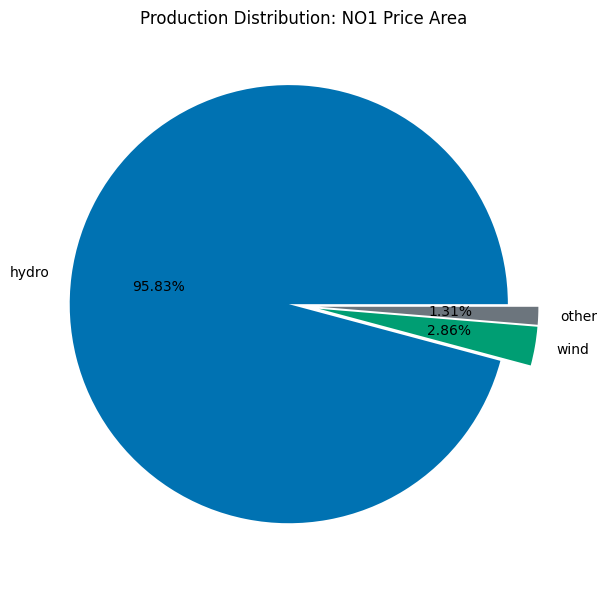

In [11]:
create_pie_chart(main_pie, title='NO1 Price Area')

## Time Plot

In [12]:
# filtering data for January and price area NO1
mask = (df_after_cassandra.index.month == 1) & (df_after_cassandra['pricearea'] == 'NO1')
df_month = df_after_cassandra[mask]

# grouping data by time and production group
time_data = df_month.groupby([df_month.index, 'productiongroup'])['quantitykwh'].sum().unstack().fillna(0)

time_data.head()

productiongroup,hydro,other,solar,thermal,wind
starttime,,,,,
2021-01-01 00:00:00+01:00,2507716.8,0.0,6.106,51369.035,937.072
2021-01-01 01:00:00+01:00,2494728.0,0.0,4.030,51673.934,649.068
2021-01-01 02:00:00+01:00,2486777.5,0.0,3.982,51457.535,144.000
2021-01-01 03:00:00+01:00,2461176.0,0.0,8.146,51644.637,217.070
2021-01-01 04:00:00+01:00,2466969.2,0.0,8.616,51897.836,505.071


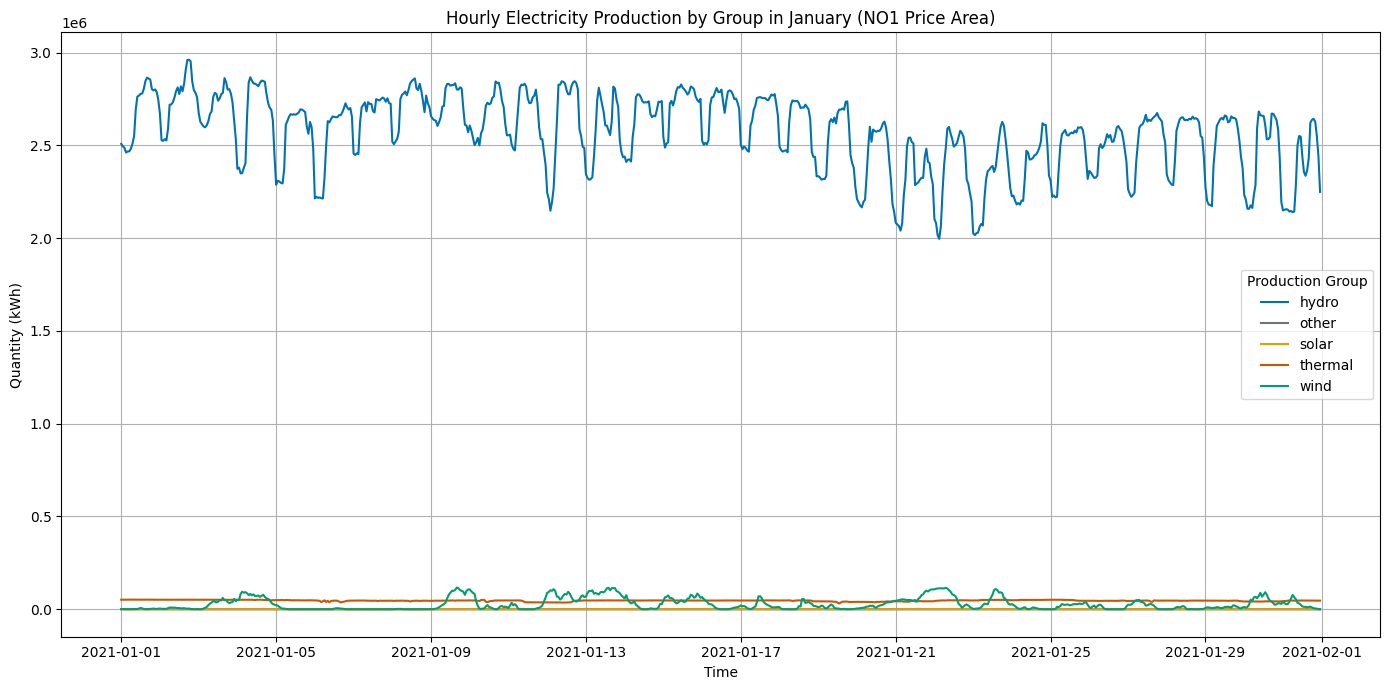

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
for label in time_data.columns:
    ax.plot(
        time_data.index,
        time_data[label],
        label=label,
        color=color_map.get(label.lower(), "#4E6067")
    )
ax.set_title('Hourly Electricity Production by Group in January (NO1 Price Area)')
ax.set_xlabel('Time')
ax.set_ylabel('Quantity (kWh)')
ax.grid()
ax.legend(title='Production Group')
plt.tight_layout()
plt.show()

## Mongo DB
Connecting and writing the Data

In [14]:
USR, PWD = open('../No_sync/MongoDB').read().splitlines()
uri = ("mongodb+srv://{}:{}@cluster0.s1en1xw.mongodb.net/?retryWrites=true&w=majority&appName=Cluster0")

client = MongoClient(uri.format(USR, PWD))
# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

database = client['electricity_production']
collection = database['data_2021']   

Pinged your deployment. You successfully connected to MongoDB!


In [15]:
# Delete all documents
result = collection.delete_many({})

# Print the number of documents deleted to confirm
print(f"Deleted {result.deleted_count} documents from the 'products' collection.")

Deleted 215353 documents from the 'products' collection.


In [16]:
data_dict_db = df_cassandra_original.to_dict(orient='records')

try:
    result = collection.insert_many(data_dict_db)
    print("Data inserted successfully. Inserted documents:", len(result.inserted_ids))    
except Exception as e:
    print("An error occurred while inserting data:", e)

Data inserted successfully. Inserted documents: 215353


In [17]:
N = 5
head_docs = collection.find().limit(N)
for doc in head_docs:
    print(doc)
print("...")
tail_docs = collection.find().sort([('starttime', -1)]).limit(N)
for doc in tail_docs:
    print(doc)


{'_id': ObjectId('68fa6c459b3e78b9cf2d99af'), 'pricearea': 'NO1', 'productiongroup': 'hydro', 'starttime': '2021-01-01T00:00:00+01:00', 'quantitykwh': 2507716.8}
{'_id': ObjectId('68fa6c459b3e78b9cf2d99b0'), 'pricearea': 'NO1', 'productiongroup': 'hydro', 'starttime': '2021-01-01T01:00:00+01:00', 'quantitykwh': 2494728.0}
{'_id': ObjectId('68fa6c459b3e78b9cf2d99b1'), 'pricearea': 'NO1', 'productiongroup': 'hydro', 'starttime': '2021-01-01T02:00:00+01:00', 'quantitykwh': 2486777.5}
{'_id': ObjectId('68fa6c459b3e78b9cf2d99b2'), 'pricearea': 'NO1', 'productiongroup': 'hydro', 'starttime': '2021-01-01T03:00:00+01:00', 'quantitykwh': 2461176.0}
{'_id': ObjectId('68fa6c459b3e78b9cf2d99b3'), 'pricearea': 'NO1', 'productiongroup': 'hydro', 'starttime': '2021-01-01T04:00:00+01:00', 'quantitykwh': 2466969.2}
...
{'_id': ObjectId('68fa6c479b3e78b9cf30a2f7'), 'pricearea': 'NO1', 'productiongroup': 'solar', 'starttime': '2021-12-31T23:00:00+01:00', 'quantitykwh': 6.874}
{'_id': ObjectId('68fa6c479b

In [18]:
client.close()